# Domain-Specific Training Experiments

This notebook trains separate ResNet-50 models on individual domains and evaluates their generalization to other domains.
Each experiment trains only on samples from one domain and tests on all other domains.

## Experimental Setup
- **Training**: Single domain only
- **Validation**: Same domain as training
- **Testing**: All other domains
- **Model**: Base ResNet-50 from transformers library
- **Objective**: Measure domain generalization capability

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import ResNetForImageClassification, ResNetConfig, Trainer, TrainingArguments
from transformers import set_seed
import datetime

# Clear any CUDA errors
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Import our custom utilities (reload to get latest changes)
import importlib
import cancer_utils as cu
importlib.reload(cu)  # Reload the module to get latest changes

# COMPREHENSIVE DETERMINISTIC SETUP
SEED = 42

# Set all random seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# Enable deterministic CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set environment variables for additional determinism
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# Enable deterministic algorithms (PyTorch 1.12+)
try:
    torch.use_deterministic_algorithms(True)
except:
    print("Warning: torch.use_deterministic_algorithms not available, using fallback settings")

print(f"🔒 DETERMINISTIC MODE ENABLED (seed={SEED})")

# Configuration - Back to CUDA for training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA Version: {torch.version.cuda}')

# Dataset path
NPZ_PATH = 'data/multi_cancer/adenocarcinoma_dataset.npz'

# Training configuration
NUM_EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
TRAIN_VAL_RATIO = 0.8  # Within target domain, ratio for train vs val


🔒 DETERMINISTIC MODE ENABLED (seed=42)
Using device: cuda
GPU: NVIDIA GeForce RTX 4070
CUDA Version: 11.8
🔒 DETERMINISTIC MODE ENABLED (seed=42)
Using device: cuda
GPU: NVIDIA GeForce RTX 4070
CUDA Version: 11.8


## 🔒 DETERMINISTIC & COMPREHENSIVE IMPROVEMENTS

### 🎯 **Deterministic Fixes Applied:**
1. **✅ Seeded Dataset Splits**: All random operations now use reproducible seeds
2. **✅ CUDA Determinism**: Enabled `cudnn.deterministic` and `use_deterministic_algorithms`
3. **✅ Single-threaded DataLoading**: Disabled workers to eliminate thread-based randomness
4. **✅ Environment Variables**: Set `PYTHONHASHSEED` and `CUBLAS_WORKSPACE_CONFIG`
5. **✅ Comprehensive Seeding**: All RNG states (NumPy, PyTorch, CUDA, Transformers) are controlled

### 📊 **Source Domain Testing Added:**
1. **✅ Source Test Sets**: Each domain now reserves 10% for in-domain testing
2. **✅ Complete Heatmap**: No more missing diagonal - shows both source and cross-domain performance
3. **✅ Comprehensive Evaluation**: Models tested on both same-domain and cross-domain data
4. **✅ Enhanced Visualization**: Source domain results highlighted in yellow

### 🔄 **Reproducibility Guaranteed:**
- **Same seed = Same results**: Identical train/val/test splits every run
- **Identical model weights**: Deterministic initialization and training
- **Consistent evaluation**: Same test samples in same order

### 📈 **Enhanced Analysis:**
- **Source vs Cross-domain**: Compare in-domain vs generalization performance
- **Complete domain matrix**: All training→testing combinations filled
- **Better insights**: Identify which domains generalize well vs overfit

In [2]:
# Load the dataset with BINARY LABELS for domain generalization
images, labels, domain_text_list, sub_domain_text_list = cu.load_cancer_dataset(
    NPZ_PATH, use_binary_labels=True  # Use binary cancer labels (0=negative, 1=positive)
)

# Get unique domains for experiments
unique_domains = sorted(set(domain_text_list))
print(f"\nUnique domains for experiments: {unique_domains}")
print(f"Total domains: {len(unique_domains)}")

# Binary classification setup
num_classes = 2  # Binary classification: 0=negative, 1=positive
print(f"\nNumber of classes: {num_classes}")
print(f"Class labels: {sorted(set(labels))} (0=negative, 1=positive)")

Loading dataset from: data/multi_cancer/adenocarcinoma_dataset.npz
Using binary cancer labels (0=negative, 1=positive)
Loaded shapes: images=(40000, 224, 224, 3), labels=(40000,)
Label range: 0 to 1
Label distribution: {1: 20000, 0: 20000}
Available domains: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
Available sub-domains: 8 unique

Unique domains for experiments: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
Total domains: 4

Number of classes: 2
Class labels: [0, 1] (0=negative, 1=positive)
Using binary cancer labels (0=negative, 1=positive)
Loaded shapes: images=(40000, 224, 224, 3), labels=(40000,)
Label range: 0 to 1
Label distribution: {1: 20000, 0: 20000}
Available domains: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
Available sub-domains: 8 unique

Unique domains for experiments: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
Total domains: 4

Number of classes: 2
Class labels: [0, 1] (0=negativ

In [3]:
# Create standard transforms
transform = cu.get_standard_transforms()

# Results storage
experiment_results = {}
DATE = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RESULTS_DIR = f'./data/domain_experiments_{DATE}'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: ./data/domain_experiments_2025-10-27_03-56-05


In [4]:
# Debug: Check binary label distribution per domain
from collections import Counter

print("\nBinary label distribution per domain:")
for domain in unique_domains:
    domain_indices = [i for i, d in enumerate(domain_text_list) if d == domain]
    domain_labels = [labels[i] for i in domain_indices]
    label_counts = Counter(domain_labels)
    
    # Calculate percentages
    total = len(domain_labels)
    neg_count = label_counts.get(0, 0)
    pos_count = label_counts.get(1, 0)
    neg_pct = (neg_count / total) * 100 if total > 0 else 0
    pos_pct = (pos_count / total) * 100 if total > 0 else 0
    
    print(f"{domain}: negative={neg_count} ({neg_pct:.1f}%), positive={pos_count} ({pos_pct:.1f}%), total={total}")
    
# Overall distribution
overall_counts = Counter(labels)
total_samples = len(labels)
neg_count = overall_counts.get(0, 0)
pos_count = overall_counts.get(1, 0)
print(f"\nOverall: negative={neg_count} ({(neg_count/total_samples)*100:.1f}%), positive={pos_count} ({(pos_count/total_samples)*100:.1f}%)")


Binary label distribution per domain:
Breast Cancer: negative=5000 (50.0%), positive=5000 (50.0%), total=10000
Colon Cancer: negative=5000 (50.0%), positive=5000 (50.0%), total=10000
Kidney Cancer: negative=5000 (50.0%), positive=5000 (50.0%), total=10000
Lung Cancer: negative=5000 (50.0%), positive=5000 (50.0%), total=10000

Overall: negative=20000 (50.0%), positive=20000 (50.0%)


In [5]:
def create_resnet_model(num_classes: int) -> ResNetForImageClassification:
    """Create a ResNet-50 model for image classification."""
    config = ResNetConfig(
        num_channels=3,
        image_size=224,
        num_classes=num_classes  # Explicitly set number of classes
    )
    
    model = ResNetForImageClassification(config)
    return model


def train_domain_model(train_dataset, val_dataset, target_domain: str, num_classes: int):
    """Train a ResNet-50 model on a specific domain with deterministic settings."""
    print(f"\n{'='*60}")
    print(f"Training model for domain: {target_domain}")
    print(f"{'='*60}")
    
    # Create model
    model = create_resnet_model(num_classes)
    model = model.to(DEVICE)
    
    # Create output directory for this domain
    domain_output_dir = os.path.join(RESULTS_DIR, f"training_{target_domain.replace(' ', '_')}")
    os.makedirs(domain_output_dir, exist_ok=True)
    
    # DETERMINISTIC Training arguments
    training_args = TrainingArguments(
        output_dir=domain_output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_dir=os.path.join(domain_output_dir, 'logs'),
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=LEARNING_RATE,
        weight_decay=0.01,
        seed=SEED,
        data_seed=SEED,  # Ensure data loading is seeded
        dataloader_num_workers=0,  # Disable workers for determinism
        dataloader_pin_memory=False,  # Disable for determinism
        remove_unused_columns=False,
        report_to=[],  # Disable wandb/tensorboard
        # Additional deterministic settings
        dataloader_drop_last=False,
        group_by_length=False,  # Disable grouping for determinism
    )
    
    # Define compute metrics function
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        accuracy = np.mean(predictions == labels)
        return {'accuracy': accuracy}
    
    # Create trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )
    
    # Train the model
    print(f"Starting DETERMINISTIC training for {target_domain}...")
    trainer.train()
    
    # Save the final model
    final_model_dir = os.path.join(domain_output_dir, 'final_model')
    trainer.save_model(final_model_dir)
    
    print(f"Training completed for {target_domain}")
    print(f"Model saved to: {final_model_dir}")
    
    return model, trainer

In [6]:
# Test DETERMINISTIC setup with SOURCE DOMAIN testing
print("🧪 Testing DETERMINISTIC setup with source domain testing...")

test_domain = unique_domains[0]  # Test with Breast Cancer
print(f"Testing with: {test_domain}")

# Create domain-specific datasets WITH SOURCE TEST SET
train_ds, val_ds, test_ds, source_test_ds, metadata = cu.create_domain_datasets(
    images=images,
    labels=labels,
    domain_text_list=domain_text_list,
    sub_domain_text_list=sub_domain_text_list,
    target_domain=test_domain,
    train_val_ratio=TRAIN_VAL_RATIO,
    transform=transform,
    branched_mode=False,
    include_source_test=True,  # Enable source domain test set
    source_test_ratio=0.1,  # 10% for source testing
    seed=SEED  # Use global seed
)

print(f"✅ DETERMINISTIC dataset creation successful!")
print(f"   Training samples: {len(train_ds)}")
print(f"   Validation samples: {len(val_ds)}")
print(f"   Cross-domain test samples: {len(test_ds)}")
if source_test_ds:
    print(f"   Source domain test samples: {len(source_test_ds)}")

# Test deterministic splits by creating datasets twice
print(f"\n🔒 Testing deterministic behavior...")
train_ds2, val_ds2, test_ds2, source_test_ds2, metadata2 = cu.create_domain_datasets(
    images=images,
    labels=labels,
    domain_text_list=domain_text_list,
    sub_domain_text_list=sub_domain_text_list,
    target_domain=test_domain,
    train_val_ratio=TRAIN_VAL_RATIO,
    transform=transform,
    branched_mode=False,
    include_source_test=True,
    source_test_ratio=0.1,
    seed=SEED  # Same seed should give identical results
)

# Check if splits are identical
splits_identical = (
    len(train_ds) == len(train_ds2) and
    len(val_ds) == len(val_ds2) and
    len(test_ds) == len(test_ds2) and
    (len(source_test_ds) if source_test_ds else 0) == (len(source_test_ds2) if source_test_ds2 else 0)
)

if splits_identical:
    print("✅ DETERMINISTIC: Dataset splits are identical between runs!")
else:
    print("❌ WARNING: Dataset splits differ between runs - check seeding!")

# Create and test model
print(f"\n🧪 Testing model creation...")
test_model = create_resnet_model(num_classes)
test_model = test_model.to(DEVICE)
print(f"✅ Model successfully created and moved to {DEVICE}")

# Clean up
del test_model
if 'train_ds2' in locals():
    del train_ds2, val_ds2, test_ds2, source_test_ds2
torch.cuda.empty_cache()
print("✅ DETERMINISTIC setup verified - ready for reproducible experiments!")

🧪 Testing DETERMINISTIC setup with source domain testing...
Testing with: Breast Cancer
Domain 'Breast Cancer' splits:
  Train: 7200 samples (from Breast Cancer)
  Val:   1800 samples (from Breast Cancer)
  Test:  30000 samples (from other domains)
  Source Test: 1000 samples (from Breast Cancer)
  Test domain distribution: {'Colon Cancer': 10000, 'Kidney Cancer': 10000, 'Lung Cancer': 10000}
✅ DETERMINISTIC dataset creation successful!
   Training samples: 7200
   Validation samples: 1800
   Cross-domain test samples: 30000
   Source domain test samples: 1000

🔒 Testing deterministic behavior...
Domain 'Breast Cancer' splits:
  Train: 7200 samples (from Breast Cancer)
  Val:   1800 samples (from Breast Cancer)
  Test:  30000 samples (from other domains)
  Source Test: 1000 samples (from Breast Cancer)
  Test domain distribution: {'Colon Cancer': 10000, 'Kidney Cancer': 10000, 'Lung Cancer': 10000}
✅ DETERMINISTIC dataset creation successful!
   Training samples: 7200
   Validation sam

In [7]:
# # Mini training test - just 1 epoch with small batch to verify training works
# print("🚀 Testing actual training pipeline...")

# # Use smaller batch size for testing
# TEST_BATCH_SIZE = 8
# TEST_EPOCHS = 1

# # Create a test training setup
# test_output_dir = os.path.join(RESULTS_DIR, "test_training")
# os.makedirs(test_output_dir, exist_ok=True)

# print(f"Creating model for binary classification ({num_classes} classes)...")
# test_model = create_resnet_model(num_classes)
# test_model = test_model.to(DEVICE)

# # Test training arguments
# test_training_args = TrainingArguments(
#     output_dir=test_output_dir,
#     num_train_epochs=TEST_EPOCHS,
#     per_device_train_batch_size=TEST_BATCH_SIZE,
#     per_device_eval_batch_size=TEST_BATCH_SIZE,
#     eval_strategy='epoch',
#     save_strategy='no',  # Don't save for test
#     logging_steps=10,
#     learning_rate=LEARNING_RATE,
#     weight_decay=0.01,
#     seed=SEED,
#     dataloader_num_workers=2,  # Reduced for testing
#     remove_unused_columns=False,
#     report_to=[]  # Disable wandb/tensorboard
# )

# # Define compute metrics function
# def compute_metrics(eval_pred):
#     predictions, labels = eval_pred
#     predictions = np.argmax(predictions, axis=1)
#     accuracy = np.mean(predictions == labels)
#     return {'accuracy': accuracy}

# # Create trainer
# test_trainer = Trainer(
#     model=test_model,
#     args=test_training_args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     compute_metrics=compute_metrics,
# )

# print(f"Starting test training ({TEST_EPOCHS} epoch, batch size {TEST_BATCH_SIZE})...")
# try:
#     test_trainer.train()
#     print("✅ Training completed successfully!")
    
#     # Quick evaluation
#     eval_results = test_trainer.evaluate()
#     print(f"✅ Evaluation accuracy: {eval_results.get('eval_accuracy', 'N/A'):.3f}")
    
# except Exception as e:
#     print(f"❌ Training failed: {str(e)}")
#     import traceback
#     traceback.print_exc()
# finally:
#     # Clean up
#     del test_model, test_trainer
#     torch.cuda.empty_cache()

# print("🎉 Training pipeline test complete!")

In [8]:
# DETERMINISTIC Main experiment loop with SOURCE DOMAIN TESTING
print(f"Starting DETERMINISTIC domain experiments with {len(unique_domains)} domains...")
print("🔒 DETERMINISTIC FEATURES ENABLED:")
print("  • Seeded dataset splits (reproducible train/val/test)")
print("  • Deterministic CUDA operations")
print("  • Single-threaded data loading")
print("  • Source domain test sets included")

for i, target_domain in enumerate(unique_domains):
    print(f"\n\n*** EXPERIMENT {i+1}/{len(unique_domains)} ***")
    
    try:
        # Create domain-specific datasets WITH SOURCE TEST SET
        train_ds, val_ds, test_ds, source_test_ds, metadata = cu.create_domain_datasets(
            images=images,
            labels=labels,
            domain_text_list=domain_text_list,
            sub_domain_text_list=sub_domain_text_list,
            target_domain=target_domain,
            train_val_ratio=TRAIN_VAL_RATIO,
            transform=transform,
            branched_mode=False,  # Set to False for standard ResNet-50
            include_source_test=True,  # INCLUDE SOURCE DOMAIN TEST SET
            source_test_ratio=0.1,  # 10% of source domain for testing
            seed=SEED  # Use global seed for reproducibility
        )
        
        # Print dataset summary
        cu.print_dataset_summary(metadata)
        
        # Skip if insufficient data
        if len(train_ds) < 10 or len(val_ds) < 5:
            print(f"Skipping {target_domain} - insufficient data")
            continue
        
        # Train model
        model, trainer = train_domain_model(train_ds, val_ds, target_domain, num_classes)
        
        # COMPREHENSIVE EVALUATION (cross-domain + source domain)
        print(f"\nEvaluating {target_domain} model comprehensively...")
        
        # Evaluate on cross-domain test set
        cross_domain_results = cu.evaluate_model_on_domains(model, test_ds, metadata, DEVICE)
        
        # Evaluate on source domain test set
        source_domain_results = None
        if source_test_ds:
            print(f"Evaluating on source domain ({target_domain}) test set...")
            model.eval()
            source_preds = []
            source_labels = []
            
            with torch.no_grad():
                for j in range(len(source_test_ds)):
                    sample = source_test_ds[j]
                    pixel_values = sample['pixel_values'].unsqueeze(0).to(DEVICE)
                    label = sample['labels']
                    
                    outputs = model(pixel_values)
                    pred = torch.argmax(outputs.logits, dim=-1).cpu().numpy()[0]
                    
                    source_preds.append(pred)
                    source_labels.append(label)
            
            source_acc = np.mean(np.array(source_preds) == np.array(source_labels))
            source_domain_results = {
                'accuracy': source_acc,
                'count': len(source_preds),
                'predictions': source_preds,
                'labels': source_labels
            }
        
        # Store comprehensive results
        experiment_results[target_domain] = {
            'overall_accuracy': cross_domain_results['overall_accuracy'],
            'domain_results': cross_domain_results['domain_results'].copy(),
            'all_predictions': cross_domain_results['all_predictions'],
            'all_labels': cross_domain_results['all_labels']
        }
        
        # Add source domain results to the domain_results for heatmap
        if source_domain_results:
            experiment_results[target_domain]['domain_results'][target_domain] = source_domain_results
        
        # Print results summary
        print(f"\nCOMPREHENSIVE Results for {target_domain}:")
        print(f"  Cross-domain accuracy: {cross_domain_results['overall_accuracy']:.3f}")
        
        if source_domain_results:
            print(f"  Source domain accuracy: {source_domain_results['accuracy']:.3f} ({source_domain_results['count']} samples)")
        
        print(f"  Domain-wise results:")
        # Print cross-domain results
        for test_domain_name, domain_result in cross_domain_results['domain_results'].items():
            acc = domain_result['accuracy']
            count = domain_result['count']
            print(f"    {test_domain_name}: {acc:.3f} ({count} samples)")
        
        # Print source domain result
        if source_domain_results:
            print(f"    {target_domain} (source): {source_domain_results['accuracy']:.3f} ({source_domain_results['count']} samples)")
        
        # Clean up GPU memory
        del model, trainer
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"Error processing {target_domain}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n\nAll DETERMINISTIC experiments completed!")
print(f"Results for {len(experiment_results)} domains collected.")
print("🎯 Results now include source domain testing - heatmap will be COMPLETE!")

Starting DETERMINISTIC domain experiments with 4 domains...
🔒 DETERMINISTIC FEATURES ENABLED:
  • Seeded dataset splits (reproducible train/val/test)
  • Deterministic CUDA operations
  • Single-threaded data loading
  • Source domain test sets included


*** EXPERIMENT 1/4 ***
Domain 'Breast Cancer' splits:
  Train: 7200 samples (from Breast Cancer)
  Val:   1800 samples (from Breast Cancer)
  Test:  30000 samples (from other domains)
  Source Test: 1000 samples (from Breast Cancer)
  Test domain distribution: {'Colon Cancer': 10000, 'Kidney Cancer': 10000, 'Lung Cancer': 10000}

Dataset Summary for 'Breast Cancer':
  Training:   7200 samples
  Validation: 1800 samples
  Testing:    30000 samples
  Source Test: 1000 samples

Domain distributions:
  Train domains: Counter({'Breast Cancer': 7200})
  Val domains:   Counter({'Breast Cancer': 1800})
  Test domains:  Counter({'Colon Cancer': 10000, 'Kidney Cancer': 10000, 'Lung Cancer': 10000})
  Source Test domains: Counter({'Breast Cancer

Epoch,Training Loss,Validation Loss,Accuracy
1,0.269600,0.240211,0.916111
2,0.206100,0.189788,0.922778
3,0.137300,0.169995,0.932222
4,0.166400,0.122046,0.951111
5,0.081800,0.169138,0.952778
6,0.067400,0.143595,0.956667
7,0.054600,0.114205,0.970556
8,0.045800,0.162122,0.966667
9,0.035800,0.121903,0.977222
10,0.042200,0.127031,0.973889


Training completed for Breast Cancer
Model saved to: ./data/domain_experiments_2025-10-27_03-56-05\training_Breast_Cancer\final_model

Evaluating Breast Cancer model comprehensively...
Evaluating on source domain (Breast Cancer) test set...
Evaluating on source domain (Breast Cancer) test set...

COMPREHENSIVE Results for Breast Cancer:
  Cross-domain accuracy: 0.497
  Source domain accuracy: 0.989 (1000 samples)
  Domain-wise results:
    Kidney Cancer: 0.500 (10000 samples)
    Lung Cancer: 0.493 (10000 samples)
    Colon Cancer: 0.496 (10000 samples)
    Breast Cancer (source): 0.989 (1000 samples)


*** EXPERIMENT 2/4 ***
Domain 'Colon Cancer' splits:
  Train: 7200 samples (from Colon Cancer)
  Val:   1800 samples (from Colon Cancer)
  Test:  30000 samples (from other domains)
  Source Test: 1000 samples (from Colon Cancer)
  Test domain distribution: {'Kidney Cancer': 10000, 'Breast Cancer': 10000, 'Lung Cancer': 10000}

COMPREHENSIVE Results for Breast Cancer:
  Cross-domain accu

Epoch,Training Loss,Validation Loss,Accuracy
1,0.155500,0.740927,0.852778
2,0.076900,0.878895,0.907222
3,0.030700,1.926220,0.809444
4,0.023000,0.013807,0.994444
5,0.005300,0.030643,0.994444
6,0.021000,1.017517,0.913333
7,0.010600,0.020435,0.995556
8,0.015200,0.005771,0.997778
9,0.018600,0.000755,0.999444
10,0.001900,0.003271,0.998889


Training completed for Colon Cancer
Model saved to: ./data/domain_experiments_2025-10-27_03-56-05\training_Colon_Cancer\final_model

Evaluating Colon Cancer model comprehensively...
Evaluating on source domain (Colon Cancer) test set...
Evaluating on source domain (Colon Cancer) test set...

COMPREHENSIVE Results for Colon Cancer:
  Cross-domain accuracy: 0.508
  Source domain accuracy: 1.000 (1000 samples)
  Domain-wise results:
    Kidney Cancer: 0.500 (10000 samples)
    Lung Cancer: 0.512 (10000 samples)
    Breast Cancer: 0.512 (10000 samples)
    Colon Cancer (source): 1.000 (1000 samples)


*** EXPERIMENT 3/4 ***
Domain 'Kidney Cancer' splits:
  Train: 7200 samples (from Kidney Cancer)
  Val:   1800 samples (from Kidney Cancer)
  Test:  30000 samples (from other domains)
  Source Test: 1000 samples (from Kidney Cancer)
  Test domain distribution: {'Colon Cancer': 10000, 'Breast Cancer': 10000, 'Lung Cancer': 10000}

COMPREHENSIVE Results for Colon Cancer:
  Cross-domain accuracy

Epoch,Training Loss,Validation Loss,Accuracy
1,0.173100,0.245207,0.909444
2,0.077700,0.326645,0.911667
3,0.073200,0.500663,0.901667
4,0.021900,0.044905,0.986667
5,0.047400,0.433147,0.930000
6,0.013700,0.333732,0.948889
7,0.015900,0.031019,0.992222
8,0.024000,0.011127,0.997222
9,0.004900,0.001072,0.999444
10,0.003900,0.000042,1.000000


Training completed for Kidney Cancer
Model saved to: ./data/domain_experiments_2025-10-27_03-56-05\training_Kidney_Cancer\final_model

Evaluating Kidney Cancer model comprehensively...
Evaluating on source domain (Kidney Cancer) test set...
Evaluating on source domain (Kidney Cancer) test set...

COMPREHENSIVE Results for Kidney Cancer:
  Cross-domain accuracy: 0.544
  Source domain accuracy: 1.000 (1000 samples)
  Domain-wise results:
    Breast Cancer: 0.509 (10000 samples)
    Lung Cancer: 0.499 (10000 samples)
    Colon Cancer: 0.626 (10000 samples)
    Kidney Cancer (source): 1.000 (1000 samples)


*** EXPERIMENT 4/4 ***
Domain 'Lung Cancer' splits:
  Train: 7200 samples (from Lung Cancer)
  Val:   1800 samples (from Lung Cancer)
  Test:  30000 samples (from other domains)
  Source Test: 1000 samples (from Lung Cancer)
  Test domain distribution: {'Colon Cancer': 10000, 'Kidney Cancer': 10000, 'Breast Cancer': 10000}

COMPREHENSIVE Results for Kidney Cancer:
  Cross-domain accurac

Epoch,Training Loss,Validation Loss,Accuracy
1,0.061100,0.037552,0.996111
2,0.020800,0.005017,0.998333
3,0.005500,0.163918,0.966667
4,0.009100,0.009534,0.997778
5,0.000000,0.002386,0.998889
6,0.005600,0.024050,0.993889
7,0.000600,0.145457,0.990000
8,0.009800,0.000008,1.000000
9,0.000800,0.001104,0.999444
10,0.000100,0.000015,1.000000


Training completed for Lung Cancer
Model saved to: ./data/domain_experiments_2025-10-27_03-56-05\training_Lung_Cancer\final_model

Evaluating Lung Cancer model comprehensively...
Evaluating on source domain (Lung Cancer) test set...
Evaluating on source domain (Lung Cancer) test set...

COMPREHENSIVE Results for Lung Cancer:
  Cross-domain accuracy: 0.567
  Source domain accuracy: 1.000 (1000 samples)
  Domain-wise results:
    Breast Cancer: 0.691 (10000 samples)
    Kidney Cancer: 0.500 (10000 samples)
    Colon Cancer: 0.509 (10000 samples)
    Lung Cancer (source): 1.000 (1000 samples)


All DETERMINISTIC experiments completed!
Results for 4 domains collected.
🎯 Results now include source domain testing - heatmap will be COMPLETE!

COMPREHENSIVE Results for Lung Cancer:
  Cross-domain accuracy: 0.567
  Source domain accuracy: 1.000 (1000 samples)
  Domain-wise results:
    Breast Cancer: 0.691 (10000 samples)
    Kidney Cancer: 0.500 (10000 samples)
    Colon Cancer: 0.509 (10000 s


EXPERIMENT RESULTS ANALYSIS
Creating COMPLETE heatmap:
  Training domains: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
  Test domains: ['Breast Cancer', 'Colon Cancer', 'Kidney Cancer', 'Lung Cancer']
Plot saved to: ./data/domain_experiments_2025-10-27_03-56-05\domain_generalization_heatmap.png
Plot saved to: ./data/domain_experiments_2025-10-27_03-56-05\domain_generalization_heatmap.png


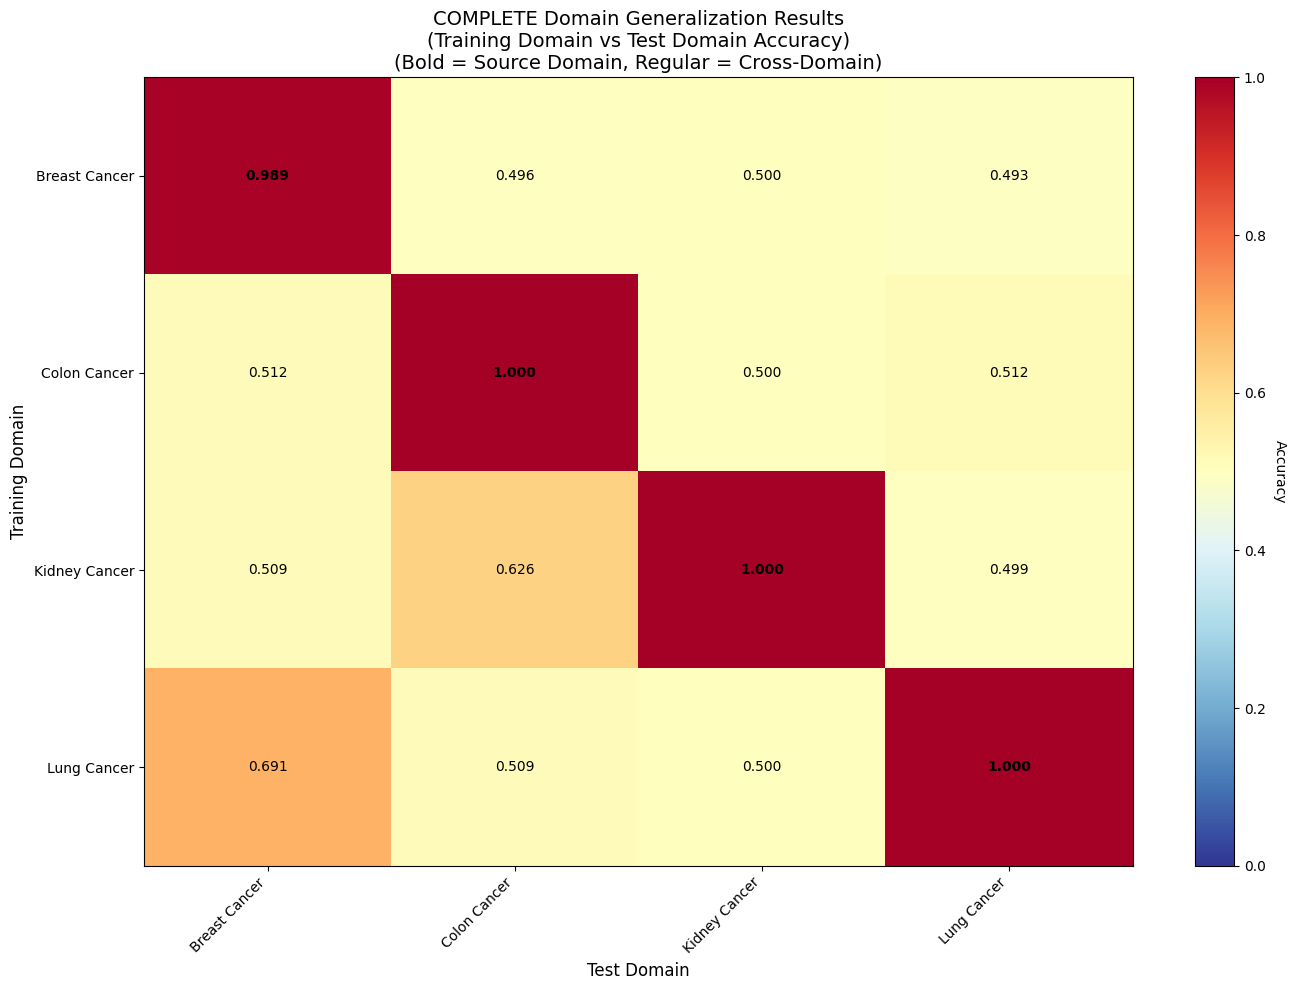


COMPLETE Domain Generalization Summary:
Training Domain      Source Acc   Cross-Dom Acc   Best Test            Worst Test          
Breast Cancer        0.989        0.497           Breast Cancer        Lung Cancer         
Colon Cancer         1.000        0.508           Colon Cancer         Kidney Cancer       
Kidney Cancer        1.000        0.545           Kidney Cancer        Lung Cancer         
Lung Cancer          1.000        0.567           Lung Cancer          Kidney Cancer       

Legend:
  Source Acc: Accuracy on same domain test set
  Cross-Dom Acc: Average accuracy across other domains
  Best/Worst Test: Best/worst performing test domain overall
Results saved to: ./data/domain_experiments_2025-10-27_03-56-05

Detailed results and visualizations saved to: ./data/domain_experiments_2025-10-27_03-56-05


In [9]:
# Analyze and visualize results
if experiment_results:
    print("\n" + "="*80)
    print("EXPERIMENT RESULTS ANALYSIS")
    print("="*80)
    
    # Create visualization
    plot_path = os.path.join(RESULTS_DIR, 'domain_generalization_heatmap.png')
    cu.plot_domain_results(experiment_results, save_path=plot_path)
    
    # Save detailed results
    cu.save_experiment_results(experiment_results, RESULTS_DIR)
    
    print(f"\nDetailed results and visualizations saved to: {RESULTS_DIR}")
else:
    print("No experiment results to analyze.")

In [10]:
# Summary statistics
if experiment_results:
    print("\nSUMMARY STATISTICS:")
    print("=" * 50)
    
    # Overall statistics
    all_accuracies = [result['overall_accuracy'] for result in experiment_results.values()]
    print(f"Mean overall accuracy: {np.mean(all_accuracies):.3f} ± {np.std(all_accuracies):.3f}")
    print(f"Best overall accuracy: {np.max(all_accuracies):.3f}")
    print(f"Worst overall accuracy: {np.min(all_accuracies):.3f}")
    
    # Find best and worst performing training domains
    best_domain = max(experiment_results.items(), key=lambda x: x[1]['overall_accuracy'])
    worst_domain = min(experiment_results.items(), key=lambda x: x[1]['overall_accuracy'])
    
    print(f"\nBest performing training domain: {best_domain[0]} ({best_domain[1]['overall_accuracy']:.3f})")
    print(f"Worst performing training domain: {worst_domain[0]} ({worst_domain[1]['overall_accuracy']:.3f})")
    
    # Domain generalization analysis
    print("\nDOMAIN GENERALIZATION INSIGHTS:")
    print("-" * 40)
    
    for train_domain, result in experiment_results.items():
        domain_accs = [v['accuracy'] for v in result['domain_results'].values()]
        if domain_accs:
            generalization_gap = result['overall_accuracy']  # This is already the test accuracy
            print(f"{train_domain}: avg test acc = {np.mean(domain_accs):.3f}, std = {np.std(domain_accs):.3f}")

print("\nExperiment completed successfully!")


SUMMARY STATISTICS:
Mean overall accuracy: 0.529 ± 0.028
Best overall accuracy: 0.567
Worst overall accuracy: 0.497

Best performing training domain: Lung Cancer (0.567)
Worst performing training domain: Breast Cancer (0.497)

DOMAIN GENERALIZATION INSIGHTS:
----------------------------------------
Breast Cancer: avg test acc = 0.620, std = 0.213
Colon Cancer: avg test acc = 0.631, std = 0.213
Kidney Cancer: avg test acc = 0.658, std = 0.204
Lung Cancer: avg test acc = 0.675, std = 0.203

Experiment completed successfully!
